In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
path = "/content/drive/MyDrive/Flood/train.csv"

df = pd.read_csv(path)

df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

Dataset Shape: (1117957, 22)

Column Names:
Index(['id', 'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManage

Missing Value Table:


,Feature,MissingValues
0,id,0
1,MonsoonIntensity,0
2,TopographyDrainage,0
3,RiverManagement,0
4,Deforestation,0
5,Urbanization,0
6,ClimateChange,0
7,DamsQuality,0
8,Siltation,0
9,AgriculturalPractices,0


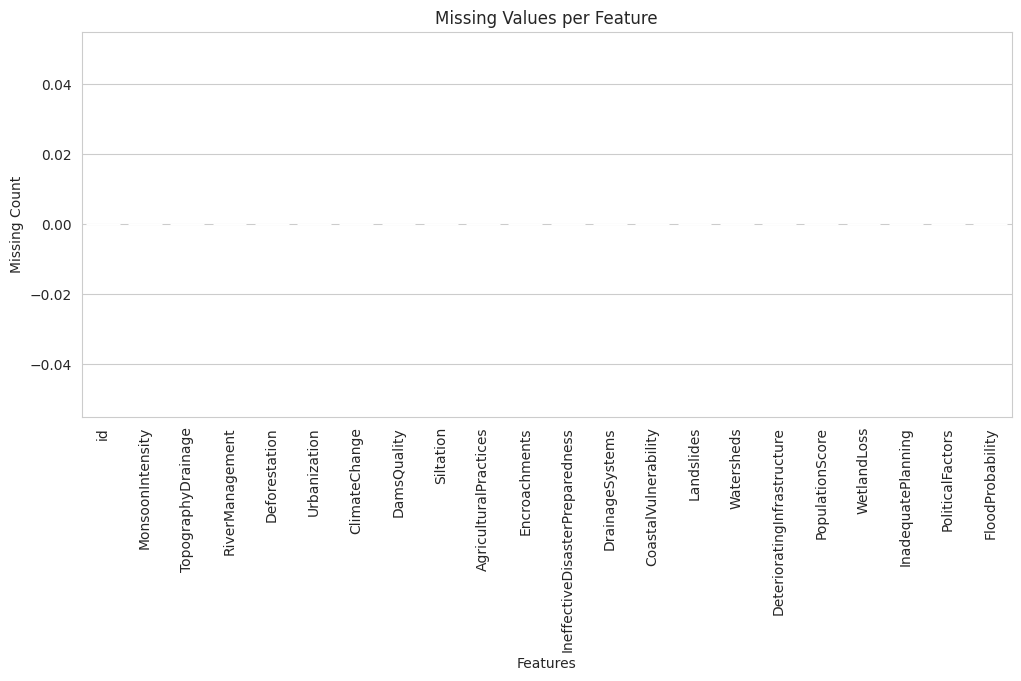

In [ ]:
# Calculate missing values
missing_values = df.isnull().sum()

# Convert to table
missing_table = pd.DataFrame({
    "Feature": missing_values.index,
    "MissingValues": missing_values.values
})

print("Missing Value Table:")
display(missing_table)

# Plot graph
plt.figure(figsize=(12,5))
sns.barplot(x=missing_table["Feature"],
            y=missing_table["MissingValues"])

plt.xticks(rotation=90)
plt.title("Missing Values per Feature")
plt.xlabel("Features")
plt.ylabel("Missing Count")

plt.show()

In [ ]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Total Duplicate Rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Total Duplicate Rows: 0
Dataset Shape After Removing Duplicates: (1117957, 22)


Unique Values Table:


,Feature,UniqueValues
0,id,1117957
1,MonsoonIntensity,17
2,TopographyDrainage,19
3,RiverManagement,17
4,Deforestation,18
5,Urbanization,18
6,ClimateChange,18
7,DamsQuality,17
8,Siltation,17
9,AgriculturalPractices,17


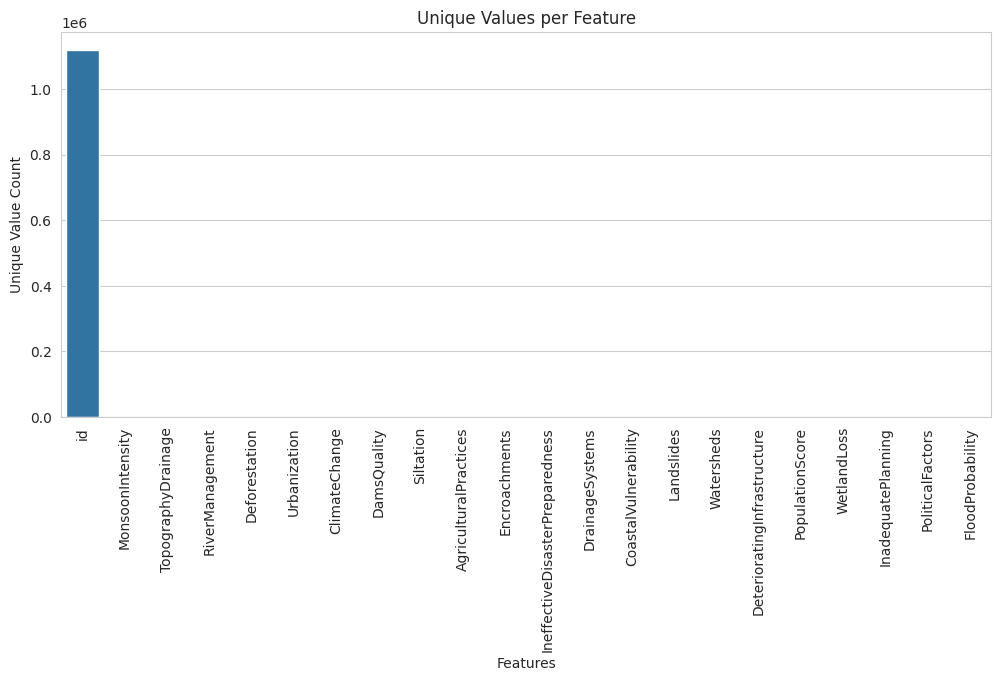

In [ ]:
# Count unique values
unique_counts = df.nunique()

# Convert to table
unique_table = pd.DataFrame({
    "Feature": unique_counts.index,
    "UniqueValues": unique_counts.values
})

print("Unique Values Table:")
display(unique_table)

# Plot graph
plt.figure(figsize=(12,5))

sns.barplot(x="Feature", y="UniqueValues", data=unique_table)

plt.xticks(rotation=90)
plt.title("Unique Values per Feature")
plt.xlabel("Features")
plt.ylabel("Unique Value Count")

plt.show()

In [ ]:
# Remove ID column because it has no predictive value
df = df.drop(columns=["id"])

print("Column 'id' removed.")

print("\nRemaining Columns:")
print(df.columns)

Column 'id' removed.

Remaining Columns:
Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='object')


Target Variable Summary:


,FloodProbability
count,1.117957e+06
mean,5.044803e-01
std,5.102610e-02
min,2.850000e-01
25%,4.700000e-01
50%,5.050000e-01
75%,5.400000e-01
max,7.250000e-01


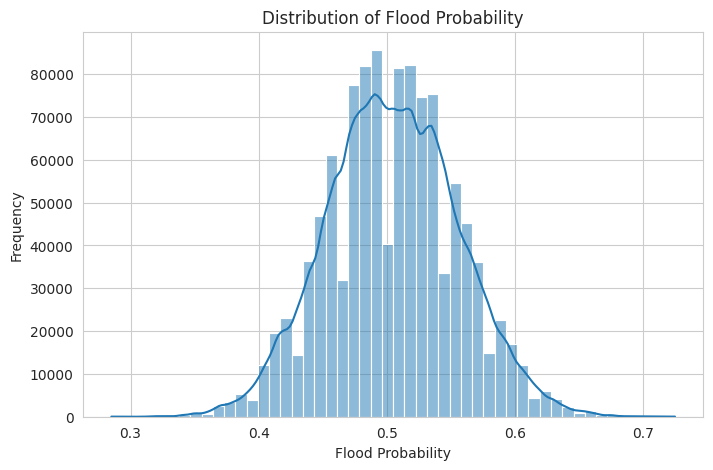

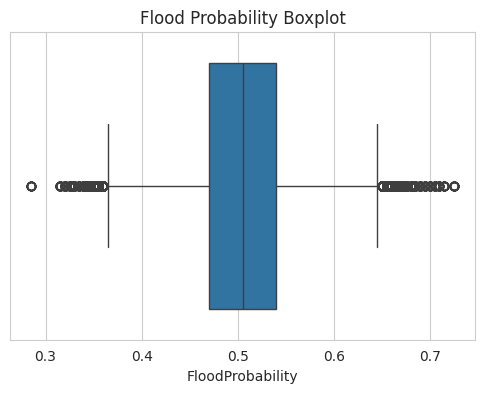

In [ ]:
# Define target variable
target = "FloodProbability"

# Summary statistics
print("Target Variable Summary:")
display(df[target].describe())

# Histogram distribution
plt.figure(figsize=(8,5))

sns.histplot(df[target], bins=50, kde=True)

plt.title("Distribution of Flood Probability")
plt.xlabel("Flood Probability")
plt.ylabel("Frequency")

plt.show()

# Boxplot
plt.figure(figsize=(6,4))

sns.boxplot(x=df[target])

plt.title("Flood Probability Boxplot")

plt.show()

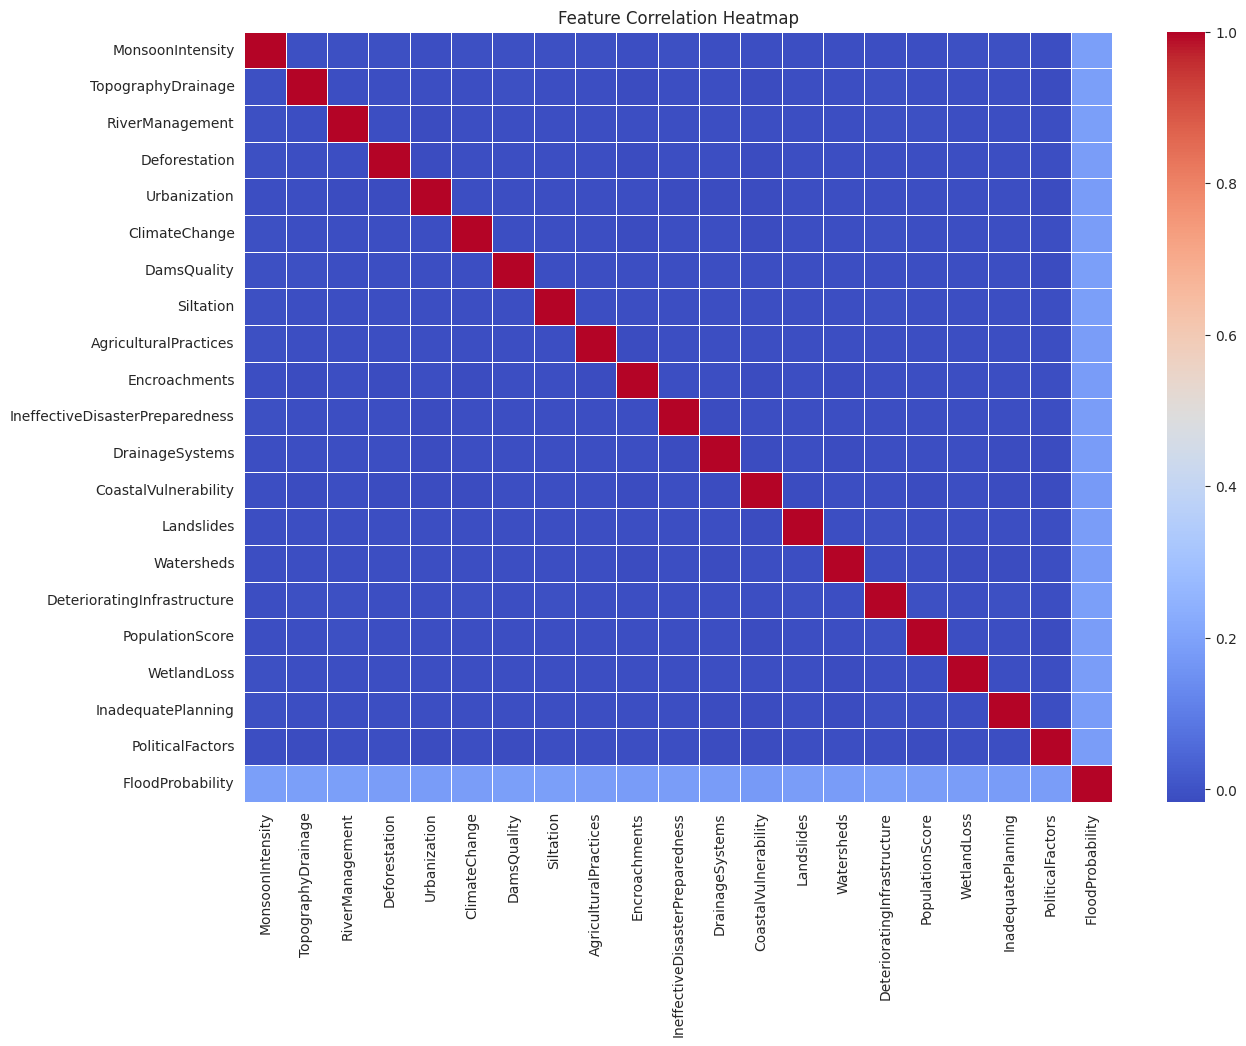

In [ ]:
# Compute correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(corr,
            cmap="coolwarm",
            annot=False,
            linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

Feature Correlation with FloodProbability:


,FloodProbability
DeterioratingInfrastructure,0.190007
MonsoonIntensity,0.189098
DamsQuality,0.187996
TopographyDrainage,0.187635
RiverManagement,0.187131
Siltation,0.186789
PopulationScore,0.185890
Landslides,0.185346
ClimateChange,0.184761
Deforestation,0.184001


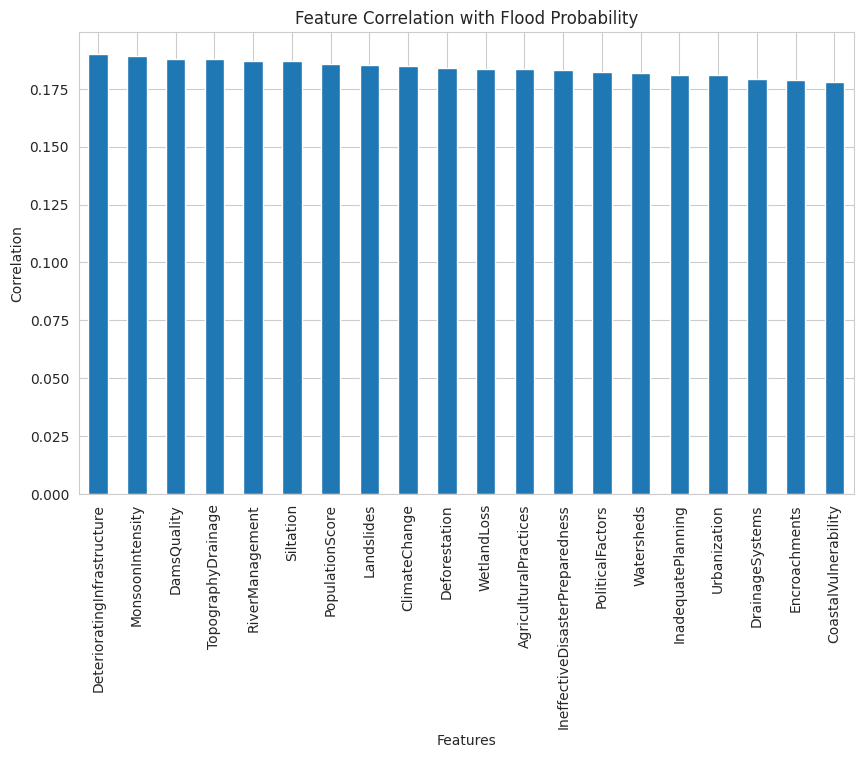

In [ ]:
# Correlation with target variable
target_corr = df.corr()["FloodProbability"].drop("FloodProbability")

# Convert to table
corr_table = target_corr.sort_values(ascending=False)

print("Feature Correlation with FloodProbability:")
display(corr_table)

# Plot graph
plt.figure(figsize=(10,6))

corr_table.plot(kind="bar")

plt.title("Feature Correlation with Flood Probability")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.show()

In [ ]:
# Separate features and target
X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]

# Train Random Forest model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X, y)

# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort values
importance = importance.sort_values(ascending=False)

print("Random Forest Feature Importance:")
display(importance)

Random Forest Feature Importance:


,0
Urbanization,0.051012
CoastalVulnerability,0.050873
DrainageSystems,0.050852
AgriculturalPractices,0.050714
PoliticalFactors,0.050684
WetlandLoss,0.050589
Siltation,0.050583
Deforestation,0.050411
Encroachments,0.050407
Landslides,0.050354


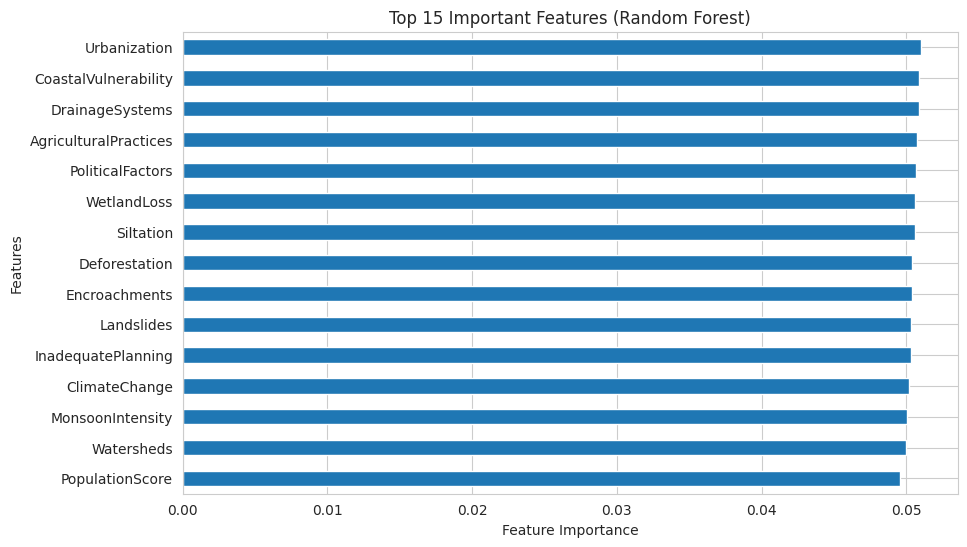

In [ ]:
# Select top 15 features
top15 = importance.head(15)

# Plot graph
plt.figure(figsize=(10,6))

top15.plot(kind="barh")

plt.title("Top 15 Important Features (Random Forest)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

F-Regression Feature Scores (top 15):


,0
DeterioratingInfrastructure,41872.852319
MonsoonIntensity,41458.498194
DamsQuality,40958.977625
TopographyDrainage,40796.044145
RiverManagement,40569.054373
Siltation,40415.827135
PopulationScore,40013.581072
Landslides,39771.570027
ClimateChange,39512.237213
Deforestation,39176.224914


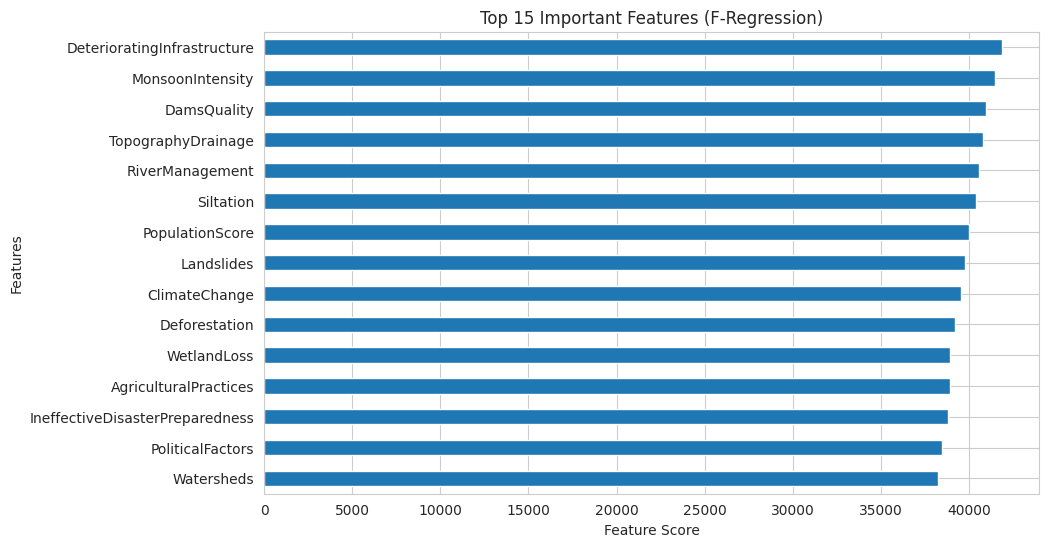

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")

# Separate features and target again
X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]

# Chi-square requires positive values, and f_regression does not
# We will use MinMaxScaler for consistency, although f_regression handles negative values.
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Feature selection using f_regression for regression tasks
chi_selector = SelectKBest(score_func=f_regression, k=15)

X_new = chi_selector.fit_transform(X_scaled, y)

# Get scores
chi_scores = pd.Series(chi_selector.scores_, index=X.columns)

chi_scores = chi_scores.sort_values(ascending=False)

print("F-Regression Feature Scores (top 15):")
display(chi_scores.head(15))

# Plot graph
plt.figure(figsize=(10,6))

chi_scores.head(15).plot(kind="barh")

plt.title("Top 15 Important Features (F-Regression)")
plt.xlabel("Feature Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Combine both feature importance results

combined_results = pd.DataFrame({
    "RandomForestImportance": importance,
    "FRegressionScore": chi_scores
})

# Sort by Random Forest importance
combined_results = combined_results.sort_values(
    by="RandomForestImportance",
    ascending=False
)

print("Combined Feature Importance Results:")
display(combined_results)

Combined Feature Importance Results:


,RandomForestImportance,FRegressionScore
Urbanization,0.051012,37805.531568
CoastalVulnerability,0.050873,36484.601120
DrainageSystems,0.050852,37136.481676
AgriculturalPractices,0.050714,38896.784247
PoliticalFactors,0.050684,38481.514051
WetlandLoss,0.050589,38910.291175
Siltation,0.050583,40415.827135
Deforestation,0.050411,39176.224914
Encroachments,0.050407,36938.125329
Landslides,0.050354,39771.570027


<Figure size 1200x700 with 0 Axes>

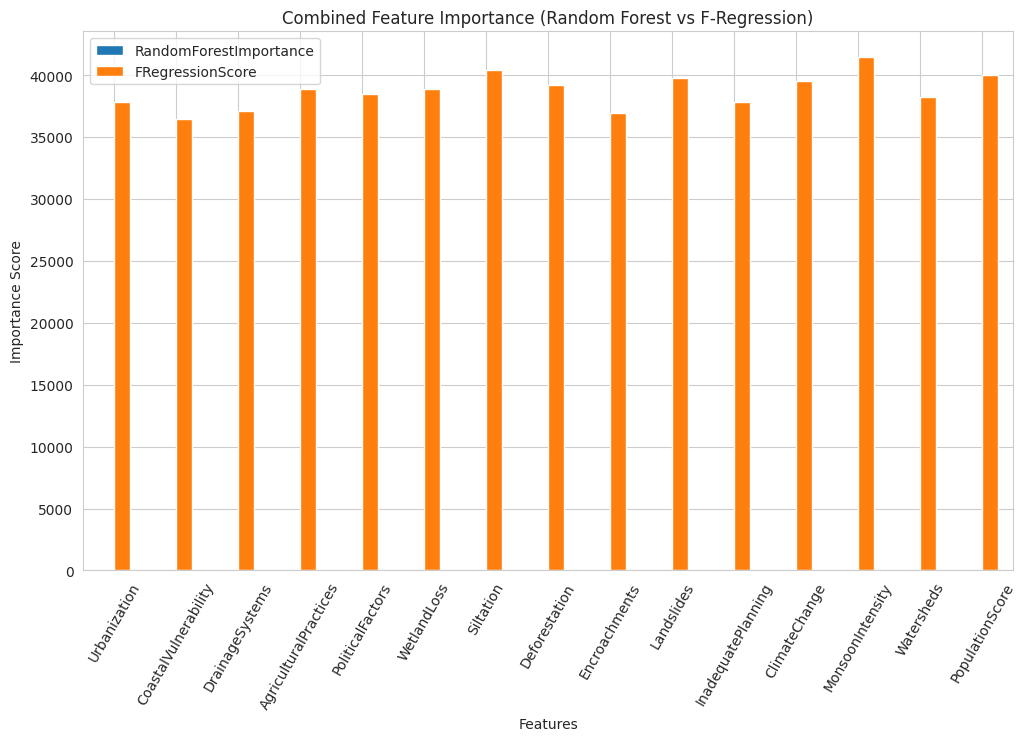

In [ ]:
plt.figure(figsize=(12,7))

combined_results.head(15).plot(
    kind="bar",
    figsize=(12,7)
)

plt.title("Combined Feature Importance (Random Forest vs F-Regression)")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=60)

plt.show()

In [ ]:
df.to_csv("/content/drive/MyDrive/Flood/processed_flood_dataset.csv", index=False)

print("Dataset saved to Google Drive")

Dataset saved to Google Drive


In [ ]:
importance.to_csv("/content/drive/MyDrive/Flood/random_forest_importance.csv")

print("Random Forest feature importance saved")

Random Forest feature importance saved


In [ ]:
chi_scores.to_csv("/content/drive/MyDrive/Flood/feature_selection_scores.csv")

print("Feature selection scores saved")

Feature selection scores saved


In [ ]:
combined_results.to_csv("/content/drive/MyDrive/Flood/combined_feature_results.csv")

print("Combined results saved")

Combined results saved
